In [1]:
import cafe

cafe.logger.setLevel("DEBUG")
cafe.settings.backend = "python_function"

[07/24/2025 09:45:31] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

Data

In [2]:
import scanpy as sc

# creating from Anndata
adata = sc.read_h5ad(f"../../tests/data/bifurcating.h5ad")
fadata = cafe.data.FateAnnData.from_anndata(adata)

cluster_key = "lineage"
fadata.obs.index = fadata.obs["cell_id"].tolist()

fadata

                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             


AnnData object with n_obs × n_vars = 1000 × 250
    obs: 'cell_id', 'from', 'to', 'time', 'lineage', 'global_time', 'lin_time_sC -> sEndC', 'lin_time_sA -> sB', 'lin_time_sB -> sBmid', 'lin_time_sBmid -> sC', 'lin_time_sD -> sEndD', 'lin_time_sBmid -> sD'
    uns: 'endpoints', 'gt_velocities', 'lineage_colors', 'startpoints', 'cfe'
    obsm: 'X_emb', 'X_umap'
    layers: 'spliced', 'unspliced'

                      DEBUG    FateAnnData add_trajectory                                                                                                                                               
                      DEBUG    plot_trajectory                                                                                                                                                          
                      DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                                
                      DEBUG    add waypoints shape is (209, 1000), finished!                                                                                                                        

<Axes: title={'center': 'lineage'}, xlabel='UMAP1', ylabel='UMAP2'>

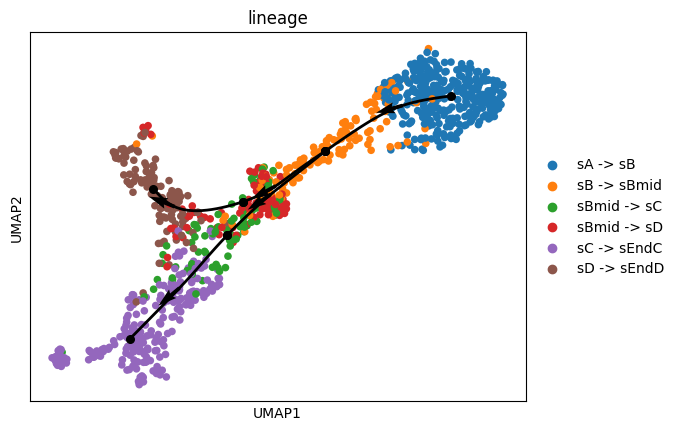

In [3]:
import pandas as pd

# 手动添加参考里程碑
milestone_network = pd.DataFrame(
    data=[
        ["sA -> sB", "sB -> sBmid"],
        ["sB -> sBmid", "sBmid -> sC"],
        ["sB -> sBmid", "sBmid -> sD"],
        ["sBmid -> sC", "sC -> sEndC"],
        ["sBmid -> sD", "sD -> sEndD"],
    ],
    columns=["from", "to"],
)

fadata.add_trajectory_mannually(milestone_network, cluster_key=cluster_key)
cafe.plot.plot_trajectory(fadata, color=cluster_key)

Ray tune, Method and plot

In [4]:
help(cafe.method.paga)

Help on FateMethod in module cafe.method.fate_method:

<cafe.method.fate_method.FateMethod object>
    PAGA trajectory inference method.
    
    Args:
        adata (ad.AnnData): AnnData object
        start_id (str): Starting cell ID for pseudotime calculation.
        repreprocess (bool, optional): whether reprocess the anndata object, including feature selection, normalization, scale, pca and neighbor computation. Defaults to True.
        filter_and_normalize_kwargs (dict, optional): Parameters for preprocess in scvelo style, refer to "scvelo.pp.filter_and_normalize"(https://scvelo.readthedocs.io/en/stable/scvelo.pp.filter_and_normalize.html). Defaults to {}.
        neighbors_kwargs (dict, optional):  Parameters for neighbor construction in scanpy style, refer to "scanpy.pp.neighbors"(https://scanpy.readthedocs.io/en/latest/api/generated/scanpy.pp.neighbors.html). Defaults to {}.
        cluster_key (str, optional): Cluster column name in adata.obs. Defaults to "clusters".
      

In [5]:
import os
from ray import tune

save_dir = f"{os.getcwd()}/img/25.07.24-raytune_paga"
base_parameters = {
    "start_id": "cell1",
    "cluster_key": cluster_key,
}

# search space, grid search
search_space = {
    "connectivity_cutoff": tune.grid_search([0.1, 0.3, 0.5]),
    "neighbors_kwargs": tune.grid_search([
        {"n_neighbors": 10},
        {"n_neighbors": 20},
        {"n_neighbors": 30},
    ]),
    # more parameters
}


def objective(config):
    # extract parameter
    parameters = {**config, **base_parameters}

    # execute method
    id = str(config)
    cafe.method.paga(fadata, **parameters, backend_name="python_function", id=id)

    # plot
    save = f"{save_dir}/{id}.jpg"
    cafe.plot.plot_trajectory(fadata, basis="umap", color=cluster_key, save=save)

    # calc metric
    metric_dict = cafe.metric.calculate_metrics(fadata, now_model=id, ref_model="ref", simplify=False, metrics=["him", "correlation"])

    return metric_dict


# Raytune
tuner = tune.Tuner(objective, param_space=search_space)
results = tuner.fit()
print(results.get_best_result(metric="correlation", mode="max").config)

(raylet) Warning: The actor ImplicitFunc is very large (9 MiB). Check that its definition is not implicitly capturing a large array or other object in scope. Tip: use ray.put() to put large objects in the Ray object store.
(pid=3003471) [07/24/2025 09:45:37] INFO                                                                                                                                                                              
(pid=3003471)                                   _____     _ _ ______    _       ______            _                                                                                                                   
(pid=3003471)                                  / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
(pid=3003471)                                 | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __             

In [6]:
# raytune is deep copy and  for every parameter combination, so it's not recorded on fadata object.
model_name_list = fadata.get_all_model_name(parse=False)
model_name_list

['ref']